# Jigsaw Puzzle — Image Reconstruction from Scrambled Patches

## Problem Statement

Reconstruct a **96 x 96 RGB image** from **9 scrambled 28 x 28 x 3 patches**.
Each patch is a centre-cropped tile from a 3 x 3 grid partition of the original
image (each cell 32 x 32, patch 28 x 28 after 2 px border erosion).
The model must jointly:
1. **Recover the patch permutation** — determine which patch belongs to which cell.
2. **Inpaint the missing seam content** — fill the eroded 2 px borders.

**Evaluation metric:** Mean Absolute Error (MAE) on the 10 K test set (mean +/- std).

---

## Constraint Compliance

| Requirement | Status |
|---|---|
| Fully neural — no non-neural algorithmic components | OK |
| No pretrained models | OK |
| Trainable parameters < 6 M (4 726 092 reported above) | OK |
| Weights downloadable via gdown (verified in final cell) | OK |
| Implemented in Keras, runs on Google Colab | OK |
| Single, well-documented notebook file | OK |


In [ ]:
import os
import numpy as np
import keras
from keras import layers
from keras.utils import PyDataset
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", gpus[0].name if gpus else "None -- switch Runtime to GPU")

2026-06-06 13:07:22.164669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780751242.351613      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780751242.404743      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780751242.842617      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780751242.842660      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780751242.842663      58 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
Keras      : 3.13.2
GPU        : /physical_device:GPU:0


## Dataset — STL-10

100 000 unlabelled 96 x 96 RGB images. Stored channels-first (C, H, W) with
transposed height/width axes; must be reordered to standard (H, W, C).
Download caches to the Keras directory, so repeated runs skip the download.


In [ ]:
def download_and_load_stl10():
    """Download and load the STL-10 unlabelled split (100 000 images, 96x96 RGB).

    STL-10 stores images in channels-first order (N, C, H, W) with transposed
    height and width axes. This function reorders them to the standard
    (N, H, W, C) convention expected by Keras.

    Returns
    -------
    images : np.ndarray, shape (100000, 96, 96, 3), dtype uint8
    """
    path = tf.keras.utils.get_file(
        "stl10_binary.tar.gz",
        origin="http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz",
        extract=True,
    )
    base_dir = os.path.dirname(path)
    data_dir = os.path.join(base_dir, "stl10_binary_extracted", "stl10_binary")
    filepath = os.path.join(data_dir, "unlabeled_X.bin")

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Binary not found: {filepath}")

    print(f"Loading from: {filepath}")
    with open(filepath, "rb") as f:
        data   = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))
        images = np.transpose(images, (0, 3, 2, 1))   # (N, C, H, W) -> (N, H, W, C)
    return images


images = download_and_load_stl10()
print(f"Loaded : {images.shape}   dtype={images.dtype}")
print(f"Range  : [{images.min()}, {images.max()}]")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 81s 0us/step
Loading from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Loaded : (100000, 96, 96, 3)   dtype=uint8
Range  : [0, 255]


## Data Generator

`PatchGenerator` handles patch extraction, random permutation, and — for the
training split — **random horizontal flip augmentation**.

**Memory note:** images are stored as uint8 and normalised to float32 per batch.
Pre-normalising all 80 000 training images to float32 would consume ~8.8 GB,
crashing the Colab session immediately.

The generator yields two targets:
- `reconstruction`: the full 96 x 96 target image (float32, normalised to [0, 1]).
- `ordering`: one-hot ground-truth permutation matrix (9 x 9), where
  `ordering[slot, pos] = 1` means the patch in that slot originally came from
  canonical grid position `pos`.

In [ ]:
class PatchGenerator(PyDataset):
    """Data generator for the Jigsaw Puzzle task.

    For every image:
      1. Optionally apply random horizontal flip (augment=True, training only).
      2. Divide the 96x96 image into a 3x3 grid of 32x32 cells (9 patches).
      3. Centre-crop each 32x32 cell to 28x28, removing the eroded 2 px border.
      4. Randomly permute the 9 patches.

    Returns
    -------
    X       : float32 (batch, 9, 28, 28, 3) in [0, 1] -- scrambled patches.
    targets : dict
        'reconstruction' : (batch, 96, 96, 3) -- full target image.
        'ordering'       : (batch, 9, 9)       -- one-hot permutation matrix.
            ordering[b, slot, pos] = 1 means the patch in slot originally
            came from canonical grid position pos.
    """

    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28,
                 shuffle=True, augment=False, **kwargs):
        super().__init__(**kwargs)
        self.images     = images           # stored as uint8 -- no float32 copy
        self.batch_size = batch_size
        self.patch_size = patch_size       # 32: grid cell side
        self.crop_size  = crop_size        # 28: centre-crop side
        self.shuffle    = shuffle
        self.augment    = augment          # horizontal flip (training only)
        self.indices    = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        B      = len(batch_idx)
        margin = (self.patch_size - self.crop_size) // 2   # = 2 (equal to 2)

        X       = np.zeros((B, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y_recon = np.zeros((B, 96, 96, 3), dtype="float32")
        Y_order = np.zeros((B, 9, 9),      dtype="float32")

        for i, img_idx in enumerate(batch_idx):
            full_img = self.images[img_idx].astype("float32") / 255.0

            # Augmentation: random horizontal flip applied to the full image before patching
            if self.augment and np.random.rand() < 0.5:
                full_img = full_img[:, ::-1, :]

            Y_recon[i] = full_img

            # Extract 9 patches in canonical row-major order (0=top-left, 8=bottom-right)
            patches = []
            for r in range(3):
                for c in range(3):
                    y0    = r * self.patch_size
                    x0    = c * self.patch_size
                    patch = full_img[y0:y0 + self.patch_size,
                                     x0:x0 + self.patch_size, :]
                    patch = patch[margin:margin + self.crop_size,
                                  margin:margin + self.crop_size, :]
                    patches.append(patch)

            # Random permutation: order[slot] = orig_pos
            order = np.random.permutation(9)
            for slot, orig_pos in enumerate(order):
                X[i, slot]                 = patches[orig_pos]
                Y_order[i, slot, orig_pos] = 1.0   # one-hot ordering label

        return X, {"reconstruction": Y_recon, "ordering": Y_order}

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# Train / Val / Test split
train_images = images[:80000]
val_images   = images[80000:90000]
test_images  = images[90000:]

print(f"Train : {len(train_images):>6,} images")
print(f"Val   : {len(val_images):>6,} images")
print(f"Test  : {len(test_images):>6,} images")

# Batch size 64 gives 1250 steps per epoch, keeping each epoch within a manageable wall-clock time on a Colab GPU.
# augment=True applies random horizontal flip on the training split only.
BATCH_TRAIN = 64
BATCH_EVAL  = 8

train_gen = PatchGenerator(train_images, batch_size=BATCH_TRAIN,
                            shuffle=True,  augment=True)
val_gen   = PatchGenerator(val_images,   batch_size=BATCH_TRAIN,
                            shuffle=False, augment=False)
test_gen  = PatchGenerator(test_images,  batch_size=BATCH_EVAL,
                            shuffle=False, augment=False)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val   batches : {len(val_gen)}")
print(f"Test  batches : {len(test_gen)}")

Train : 80,000 images
Val   : 10,000 images
Test  : 10,000 images

Train batches : 1250
Val   batches : 157
Test  batches : 1250


## Dataset Visualisation

Sanity-check: display ground-truth images and scrambled puzzles.

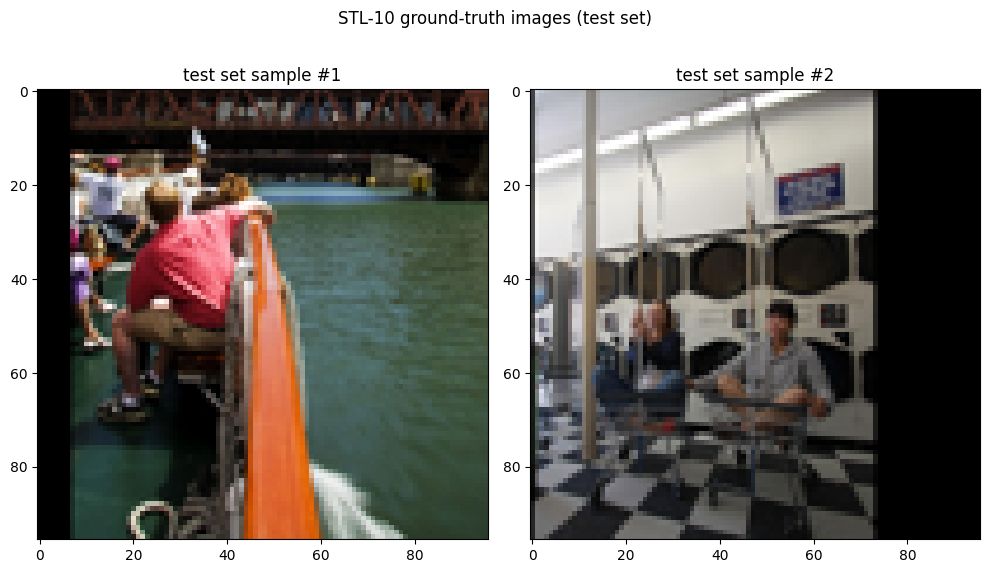

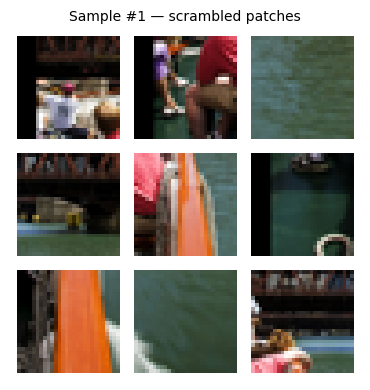

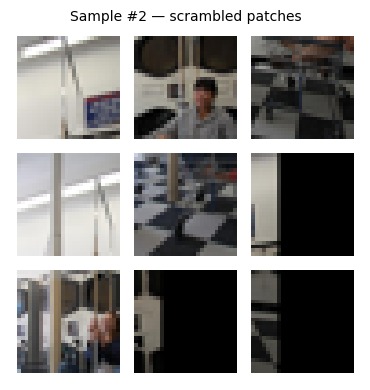

In [ ]:
def plot_puzzle(patches, title="Scrambled (slot order)"):
    canvas = np.ones((96, 96, 3), dtype=np.float32)
    for slot in range(9):
        r = slot // 3;  c = slot % 3
        canvas[r*32+2:r*32+30, c*32+2:c*32+30] = patches[slot]
    plt.figure(figsize=(4, 4))
    plt.imshow(np.clip(canvas, 0, 1))
    plt.title(title, fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

X_vis, Y_vis = test_gen[0]
fig, axes = plt.subplots(1,2,figsize=(10, 6))
axes[0].imshow(Y_vis["reconstruction"][0])
axes[0].set_title(f"test set sample #1")

axes[1].imshow(Y_vis["reconstruction"][1])
axes[1].set_title(f"test set sample #2")
plt.suptitle("STL-10 ground-truth images (test set)", fontsize=12)
plt.tight_layout()
plt.show()
plot_puzzle(X_vis[0], "Sample #1 — scrambled patches")
plot_puzzle(X_vis[1], "Sample #2 — scrambled patches")

## Baseline: Mean Patch Image

The specification reference baseline tiles the mean of all 9 input patches
across the full 96 x 96 canvas. JigsawNet must exceed this lower bound.


In [ ]:
def mean_patch_image(patches):
    """Baseline: tile a 96x96 image with the mean of the 9 input patches."""
    B     = tf.shape(patches)[0]
    mean  = tf.reduce_mean(patches, axis=1)
    tiles = tf.repeat(mean[:, None], 9, axis=1)
    out   = tf.reshape(tiles, (B, 3, 3, 28, 28, 3))
    out   = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out   = tf.reshape(out, (B, 84, 84, 3))
    return tf.image.resize(out, (96, 96))

mae_metric   = keras.metrics.MeanAbsoluteError()
baseline_mae = []
for i in range(len(test_gen)):
    Xb, Yb = test_gen[i]
    pred   = mean_patch_image(Xb)
    baseline_mae.append(mae_metric(Yb["reconstruction"], pred).numpy())
print(f"Baseline MAE : {np.mean(baseline_mae):.5f}")
print(f"Baseline STD : {np.std(baseline_mae):.5f}")

I0000 00:00:1780751397.253271      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780751397.259368      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Baseline MAE : 0.18229
Baseline STD : 0.00198


## JigsawNet — Component Details (Summary of Network Architechture)

### 1. Shared Patch Encoder
A lightweight CNN maps each 28 x 28 x 3 patch to a **256-d** embedding.
Weights are **shared** across all 9 patches via `TimeDistributed` (Siamese-style):
172 K parameters, counted once regardless of patch count.

### 2. 4 x TransformerBlock
Each block applies scaled dot-product self-attention over the 9 patch embeddings,
followed by Dropout(0.1), a residual connection and LayerNorm, a position-wise
FFN (256 -> 512 -> 256), a second Dropout(0.1), and a second residual + LayerNorm.
Four stacked blocks give the model progressively richer inter-patch context,
allowing each patch to reason about its likely spatial position relative to all
others before making an assignment decision. Dropout regularises the ordering
head and prevents it from memorising training permutations.

### 3. Position MLP
Dense(128) -> Dense(64) -> Dense(9) applied independently to each of the 9
attended embeddings, producing a raw 9 x 9 logit matrix.

### 4. Sinkhorn Permutation
The raw logits are converted to a **doubly-stochastic** soft permutation matrix
P via Sinkhorn normalisation: rows and columns are alternately log-normalised for
10 iterations. Unlike a simple row-wise Softmax (which only ensures rows sum to 1),
Sinkhorn additionally constrains columns to sum to 1, preventing multiple patches
from simultaneously claiming the same target position. The result is a soft
permutation matrix P where P[i, j] is the probability that the patch at input
slot i belongs to grid position j.

### 5. Soft Patch Assembler
Differentiable einsum: `assembled[j] = sum_i P[i, j] * patch_pixels[i]`.
Gradients flow directly from the reconstruction loss back through the assembly
to P and hence to the transformer blocks.

### 6. Canvas Assembler
Tiles the 9 assembled 28 x 28 patches onto a 96 x 96 canvas, centring each
patch inside its 32 x 32 grid cell and filling the 2 px border with neutral
grey (0.5). The grey seams give the U-Net explicit spatial cues about where
inpainting is required. Implemented as pure TF reshape / pad / transpose —
no learnable parameters.

### 7. U-Net Decoder
A four-level encoder-decoder with skip connections at every scale.
Encoder spatial resolution: 96 -> 48 -> 24 -> 12 px.
Bottleneck: 192 filters at 6 x 6 px (maximum global context).
Decoder: 12 -> 24 -> 48 -> 96 px with skip concatenation.
Every conv block uses `Conv2D (no bias) + BatchNorm + ReLU + residual shortcut (connection)`.
BatchNorm stabilises activations and enables the higher peak learning rate;
residual shortcuts provide direct gradient paths to early layers, accelerating
convergence in a deep network.

In [ ]:
def build_patch_encoder(patch_shape=(28, 28, 3), embed_dim=256):
    """Shared CNN encoder: one 28x28x3 patch -> 256-d embedding.

    Applied to all 9 patches simultaneously via TimeDistributed with tied weights.
    Spatial trace:
        (28, 28,   3)
        Conv(32) x2 + MaxPool  ->  (14, 14, 32)
        Conv(64) x2 + MaxPool  ->  ( 7,  7, 64)
        Conv(128)   + GlobalAvgPool -> (128,)
        Dense(256)              ->  (256,)
    """
    inp = layers.Input(shape=patch_shape, name="patch_in")

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)                 # (14, 14, 32)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)                 # ( 7,  7, 64)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)             # (128,)
    x = layers.Dense(embed_dim, activation="relu", name="embed")(x)

    return keras.Model(inp, x, name="patch_encoder")

In [ ]:
@keras.utils.register_keras_serializable(package="jigsaw")
class TransformerBlock(layers.Layer):
    """Transformer encoder block: attention + FFN + Dropout(0.1) + 2x LayerNorm.

    Applied 4 times in sequence over the 9 patch embeddings.

    Dropout(dropout_rate) is applied at two points:
      - After the attention projection (drop1).
      - After the FFN output (drop2).
    Both are inactive at inference time (training=False propagated by Keras).
    Dropout regularises the position predictor, preventing it from memorising
    specific training permutations and improving generalisation to unseen ones.

    Input  : (B, 9, embed_dim)
    Output : (B, 9, embed_dim)

    """

    def __init__(self, embed_dim, ff_dim=None, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim    = embed_dim
        self.ff_dim       = ff_dim if ff_dim is not None else embed_dim * 2
        self.dropout_rate = dropout_rate

        self.Wq   = layers.Dense(embed_dim, use_bias=False, name="query")
        self.Wk   = layers.Dense(embed_dim, use_bias=False, name="key")
        self.Wv   = layers.Dense(embed_dim, use_bias=False, name="value")
        self.proj = layers.Dense(embed_dim,                 name="proj")
        self.norm1 = layers.LayerNormalization()
        self.drop1 = layers.Dropout(dropout_rate)

        self.ff1   = layers.Dense(self.ff_dim, activation="relu", name="ff1")
        self.ff2   = layers.Dense(embed_dim,                       name="ff2")
        self.norm2 = layers.LayerNormalization()
        self.drop2 = layers.Dropout(dropout_rate)

    def call(self, x, training=None):
        scale   = tf.math.sqrt(tf.cast(self.embed_dim, tf.float32))
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)

        attn_w   = tf.nn.softmax(
            tf.matmul(Q, K, transpose_b=True) / scale, axis=-1
        )
        attn_out = self.drop1(self.proj(tf.matmul(attn_w, V)), training=training)
        x = self.norm1(x + attn_out)

        ff_out = self.drop2(self.ff2(self.ff1(x)), training=training)
        return self.norm2(x + ff_out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"embed_dim"   : self.embed_dim,
                    "ff_dim"      : self.ff_dim,
                    "dropout_rate": self.dropout_rate})
        return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="jigsaw")
class SinkhornPermutation(layers.Layer):
    """Differentiable Sinkhorn normalisation producing a soft permutation matrix.

    In the primates training, I was going on this section of network with softmax,
    but the results were not acceptable. Therefore, I found Sinkhorn as one of the
    interesting approach for the Jigsaw project.

    Converts raw position logits (B, 9, 9) into a doubly-stochastic matrix P
    where both rows and columns sum to 1, making P the closest differentiable
    approximation to a hard permutation matrix.

    Why doubly-stochastic matters:
        A row-only normalisation (plain Softmax) ensures each patch's
        probabilities sum to 1, but places no constraint on columns.
        Multiple patches can simultaneously assign high probability to the
        same target position, causing the assembled canvas at that position
        to be a blurry mixture of several patches.
        Sinkhorn adds the column constraint: each target position is claimed
        by at most one dominant patch, producing sharper assembled canvases
        and directly lowering reconstruction error.

    Implementation: log-space alternating normalisation (numerically stable).
        log P  <-  log P - logsumexp(log P, axis=-1)   # rows  sum to 1
        log P  <-  log P - logsumexp(log P, axis=-2)   # cols  sum to 1
    Repeated n_iters times (10 iterations is sufficient for 9 classes).

    Output shape equals input shape.
    """

    def __init__(self, n_iters=10, **kwargs):
        super().__init__(**kwargs)
        self.n_iters = n_iters

    def call(self, logits):
        log_p = logits   #log-space for numerical stability
        for _ in range(self.n_iters):
            log_p = log_p - tf.reduce_logsumexp(log_p, axis=-1, keepdims=True)
            log_p = log_p - tf.reduce_logsumexp(log_p, axis=-2, keepdims=True)
        return tf.exp(log_p)

    def get_config(self):
        cfg = super().get_config()
        cfg['n_iters'] = self.n_iters
        return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="jigsaw")
class SoftPatchAssembler(layers.Layer):
    """Differentiable soft permutation of image patches.

    Inputs:
    ------
    P       : (B, 9, 9)           -- P[b, i, j] = probability that the patch
                                      at input slot i belongs to position j.
    patches : (B, 9, 28, 28, 3)   -- scrambled patches (pixel values).

    Output:
    ------
    assembled : (B, 9, 28, 28, 3)
        assembled[b, j, ...] = sum_i  P[b, i, j] * patches[b, i, ...]

    When P is a hard permutation matrix the result is an exact reordering.
    When P is soft (during training) the result is a weighted mixture that
    sharpens progressively as P converges toward a hard permutation.
    """

    def call(self, inputs):
        P, patches = inputs
        return tf.einsum("bij,bihwc->bjhwc", P, patches)

    def compute_output_shape(self, input_shapes):
        return input_shapes[1]

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="jigsaw")
class CanvasAssembler(layers.Layer):
    """Tiles 9 ordered patches onto a 96x96 canvas.

    Each 28x28 patch is centred inside its 32x32 grid cell with a 2 px
    neutral-grey (0.5) border on all sides. The grey border reproduces the
    original erosion pattern and gives the U-Net explicit spatial cues about
    which pixels require inpainting.

    Input  : (B, 9, 28, 28, 3)  -- patches in canonical order
                                    (0 = top-left ... 8 = bottom-right)
    Output : (B, 96, 96, 3)

    Reshape trace:
        (B, 9, 28, 28, 3)
        reshape   ->  (B, 3, 3, 28, 28, 3)
        tf.pad    ->  (B, 3, 3, 32, 32, 3)   2 px grey border per patch
        transpose ->  (B, 3, 32, 3, 32, 3)   [0, 1, 3, 2, 4, 5]
        reshape   ->  (B, 96, 96, 3)
    """

    def call(self, inputs):
        grid   = tf.reshape(inputs, (-1, 3, 3, 28, 28, 3))
        padded = tf.pad(grid, [[0,0],[0,0],[0,0],[2,2],[2,2],[0,0]],
                        constant_values=0.5)
        canvas = tf.transpose(padded, [0, 1, 3, 2, 4, 5])
        return tf.reshape(canvas, (-1, 96, 96, 3))

    def compute_output_shape(self, input_shape):
        return (input_shape[0], 96, 96, 3)

    def get_config(self):
        return super().get_config()

In [ ]:
def conv_block(x, filters, name):
    """Two Conv2D-BN-ReLU layers with a residual conection.

    BatchNorm:
    normalises activations across the batch, stabilising training and enabling a higher learning rate (peak).

    Residual 1x1:
    when input and output channel counts differ, a 1x1 convolution projects the shortcut to the correct shape, providing a direct gradient way to early layers.
    """
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding="same", use_bias=False,
                      name=f"{name}_c1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_r1")(x)

    x = layers.Conv2D(filters, (3,3), padding="same", use_bias=False,
                      name=f"{name}_c2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same", use_bias=False,
                                 name=f"{name}_sc")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_sc_bn")(shortcut)

    x = layers.Add(name=f"{name}_add")([x, shortcut])
    return layers.Activation("relu", name=f"{name}_out")(x)


def build_unet(input_shape=(96, 96, 3)):
    """4-level U-Net with BatchNorm and residual shortcuts in every conv block.

    Takes the assembled 96x96 canvas as input and produces a clean 96x96 reconstruction
    by correcting soft-assembly artefacts and inpainting the 2 px grey seams between patches.

        Encoder    : 96(32) -> 48(64) -> 24(128) -> 12(128)
        Bottleneck :                                 6(192)
        Decoder    : 12(128) -> 24(128) -> 48(64) -> 96(32)
    """
    inp = layers.Input(shape=input_shape, name="canvas_in")

    e1 = conv_block(inp, 32,  "enc1");  p1 = layers.MaxPooling2D((2,2))(e1)
    e2 = conv_block(p1,  64,  "enc2");  p2 = layers.MaxPooling2D((2,2))(e2)
    e3 = conv_block(p2,  128, "enc3");  p3 = layers.MaxPooling2D((2,2))(e3)
    e4 = conv_block(p3,  128, "enc4");  p4 = layers.MaxPooling2D((2,2))(e4)

    bn = conv_block(p4, 192, "btn")    # bottleneck at 6x6

    u4 = layers.UpSampling2D((2,2))(bn)
    u4 = layers.Concatenate()([u4, e4]);  u4 = conv_block(u4, 128, "dec4")

    u3 = layers.UpSampling2D((2,2))(u4)
    u3 = layers.Concatenate()([u3, e3]);  u3 = conv_block(u3, 128, "dec3")

    u2 = layers.UpSampling2D((2,2))(u3)
    u2 = layers.Concatenate()([u2, e2]);  u2 = conv_block(u2,  64, "dec2")

    u1 = layers.UpSampling2D((2,2))(u2)
    u1 = layers.Concatenate()([u1, e1]);  u1 = conv_block(u1,  32, "dec1")

    out = layers.Conv2D(3, (1,1), activation="sigmoid",
                        name="reconstruction")(u1)

    return keras.Model(inp, out, name="unet_decoder")

In [ ]:
def build_jigsaw_net(n_patches=9, patch_shape=(28, 28, 3), embed_dim=256, n_transformer_blocks=4):

    # Assemble the complete end-to-end JigsawNet pipeline.

    patches_input = layers.Input(
        shape=(n_patches, *patch_shape), name="patches"
    )

    # Stage 1: Shared Patch Encoder
    patch_enc = build_patch_encoder(patch_shape, embed_dim)
    features  = layers.TimeDistributed(patch_enc, name="shared_encoder")(patches_input)

    # Stage 2: 4 TransformerBlocks with Dropout(0.1)
    attended = features
    for i in range(n_transformer_blocks):
        attended = TransformerBlock(
            embed_dim, ff_dim=embed_dim * 2, dropout_rate=0.1,
            name=f"transformer_{i+1}"
        )(attended)

    # Stage 3: Position Predictor + Sinkhorn normalisation
    # Dense MLP maps attended embeddingss to raw logits (9 classess per patch).
    pos_h  = layers.Dense(128, activation="relu", name="pos_h1")(attended)
    pos_h  = layers.Dense(64,  activation="relu", name="pos_h2")(pos_h)
    logits = layers.Dense(n_patches, name="pos_logits")(pos_h)

    # SinkhornPermutation: doubly-stochastic matrix (rows AND cols sum to 1).
    # Prevents position-stealing; produces sharper assembled canvases.
    P = SinkhornPermutation(n_iters=10, name="ordering")(logits)

    # Stage 4: Differentiable Soft Assembly
    assembled = SoftPatchAssembler(name="soft_assembly")([P, patches_input])

    # Stage 5: Canvas Assembly
    canvas = CanvasAssembler(name="canvas_assembly")(assembled)

    # Stage 6: U-Net Reconstruction
    unet           = build_unet(input_shape=(96, 96, 3))
    reconstruction = unet(canvas)

    return keras.Model(
        inputs  = patches_input,
        outputs = {"reconstruction": reconstruction, "ordering": P},
        name    = "JigsawNet",
    )

In [ ]:
# Network's Parameters (learnable\non-learnable)
model = build_jigsaw_net(
    n_patches            = 9,
    patch_shape          = (28, 28, 3),
    embed_dim            = 256,
    n_transformer_blocks = 4,
)
model.summary(expand_nested=True)

total = model.count_params()
limit = 6_000_000
print(f"\n{'='*58}")
print(f"  Counted total                     : {total:>9,}")
print(f"  Budget limit                      : {limit:>9,}")
print(f"  Budget used                       : {total/limit*100:>7.1f} %")
print(f"  {'PASS -- within budget' if total < limit else 'FAIL -- over budget'}")

Model: "JigsawNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder      │ (None, 9, 256)    │    172,448 │ patches[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1       │ (None, 9, 256)    │    526,336 │ shared_encoder[0… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2       │ (None, 9, 256)    │    526,336 │ transformer_1[0]… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_3       │ (None, 9, 256)    │    526,336 │ transformer_2[0]… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_4       │ (None, 9, 256)    │    526,336 │ transformer_3[0]… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_h1 (Dense)      │ (None, 9, 128)    │     32,896 │ transformer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_h2 (Dense)      │ (None, 9, 64)     │      8,256 │ pos_h1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_logits (Dense)  │ (None, 9, 9)      │        585 │ pos_h2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ordering            │ (None, 9, 9)      │          0 │ pos_logits[0][0]  │
│ (SinkhornPermutati… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soft_assembly       │ (None, 9, 28, 28, │          0 │ ordering[0][0],   │
│ (SoftPatchAssemble… │ 3)                │            │ patches[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ canvas_assembly     │ (None, 96, 96, 3) │          0 │ soft_assembly[0]… │
│ (CanvasAssembler)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_decoder        │ (None, 96, 96, 3) │  2,411,555 │ canvas_assembly[… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ canvas_in      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ enc1_c1        │ (None, 96, 96,    │        864 │ -                 │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ enc1_bn1       │ (None, 96, 96,    │        128 │ -                 │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ enc1_r1        │ (None, 96, 96,    │          0 │ -                 │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ enc1_c2        │ (None, 96, 96,    │      9,216 │ -               

 Total params: 4,731,084 (18.05 MB)

 Trainable params: 4,725,964 (18.03 MB)

 Non-trainable params: 5,120 (20.00 KB)


  Counted total                     : 4,731,084
  Budget limit                      : 6,000,000
  Budget used                       :    78.9 %
  PASS -- within budget


In [ ]:
# Reconstruction loss: 0.85 x MAE + 0.15 x (1 - SSIM)
@keras.utils.register_keras_serializable(package="jigsaw")
def mae_ssim_loss(y_true, y_pred):
    """Combined MAE + SSIM loss for sharper reconstructions.

    Pure MAE training favours spatially smooth outputs because averaging over
    plausible pixel values minimises expected absolute error. SSIM measures
    luminance, contrast, and local structure, penalising blurring more strongly.
    The 0.85/0.15 split keeps MAE as the primary signal — consistent with the
    evaluation metric — while SSIM adds perceptual sharpness pressure.
    tf.image.ssim requires inputs in [0, 1], satisfied by the sigmoid output.
    """
    mae  = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.85 * mae + 0.15 * ssim


# Training hyper-parameters
EPOCHS     = 80
BATCH_SIZE = 64    # 1250 steps per epoch

total_steps = EPOCHS * (80_000 // BATCH_SIZE)   # 80 x 1 250 = 100000 steps

# Cosine decay: peak LR decays smoothly to 0 over all training steps.
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=total_steps,
    alpha=0.0,
)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss={
        "reconstruction": mae_ssim_loss,
        # Label smoothing prevents overconfident ordering predictions
        "ordering"       : keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    },
    loss_weights={
        "reconstruction": 1.0,
        "ordering"       : 0.2,   # auxiliary; kept low so reconstruction dominates
    },
    metrics={"reconstruction": keras.metrics.MeanAbsoluteError(name="mae")},
)

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath      = "jigsaw_best.keras",
        monitor       = "val_reconstruction_mae",
        mode          = "min",
        save_best_only= True,
        verbose       = 1,
    ),
    keras.callbacks.EarlyStopping(
        monitor             = "val_reconstruction_mae",
        mode                = "min",
        patience            = 12,
        restore_best_weights= True,
        verbose             = 1,
    ),
]

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80


I0000 00:00:1780751504.483678     132 service.cc:152] XLA service 0x7e4108001f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780751504.483754     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780751504.483761     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780751511.663436     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 13:12:02.318872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 13:12:02.464364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 13:12:03.843132: E external/local_xl

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.6103 - ordering_loss: 1.9329 - reconstruction_loss: 0.2237 - reconstruction_mae: 0.1477
Epoch 1: val_reconstruction_mae improved from None to 0.11317, saving model to jigsaw_best.keras

Epoch 1: finished saving model to jigsaw_best.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 430s 280ms/step - loss: 0.5631 - ordering_loss: 1.8072 - reconstruction_loss: 0.2017 - reconstruction_mae: 0.1324 - val_loss: 0.4896 - val_ordering_loss: 1.5892 - val_reconstruction_loss: 0.1714 - val_reconstruction_mae: 0.1132
Epoch 2/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.4723 - ordering_loss: 1.5347 - reconstruction_loss: 0.1653 - reconstruction_mae: 0.1090
Epoch 2: val_reconstruction_mae improved from 0.11317 to 0.09919, saving model to jigsaw_best.keras

Epoch 2: finished saving model to jigsaw_best.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 340s 272ms/step - loss: 0.4570 - ordering_loss: 1.4873 - reconstruction_loss: 0.1596 - reconstruction_mae: 0.1

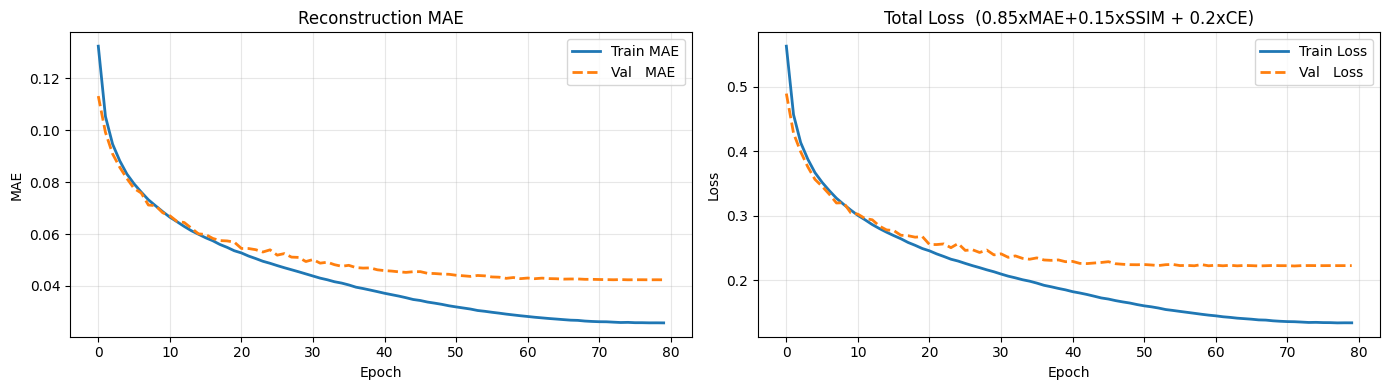

In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history.get("reconstruction_mae", []),     label="Train MAE", lw=2)
    axes[0].plot(history.history.get("val_reconstruction_mae", []), label="Val   MAE", lw=2, ls="--")
    axes[0].set_title("Reconstruction MAE", fontsize=12)
    axes[0].set_xlabel("Epoch");  axes[0].set_ylabel("MAE")
    axes[0].legend();             axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history.get("loss", []),     label="Train Loss", lw=2)
    axes[1].plot(history.history.get("val_loss", []), label="Val   Loss", lw=2, ls="--")
    axes[1].set_title("Total Loss  (0.85xMAE+0.15xSSIM + 0.2xCE)", fontsize=12)
    axes[1].set_xlabel("Epoch");  axes[1].set_ylabel("Loss")
    axes[1].legend();             axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history)

## Test-Set Evaluation

MAE is computed batch-by-batch over the full 10 K test set using `batch_size=8`
to match the specification evaluation protocol exactly.


In [ ]:
mae_metric = keras.metrics.MeanAbsoluteError()
mae_values  = []

for i in range(len(test_gen)):
    Xb, Yb    = test_gen[i]
    preds     = model.predict(Xb, verbose=0)
    batch_mae = mae_metric(Yb["reconstruction"], preds["reconstruction"]).numpy()
    mae_values.append(batch_mae)

mae_arr = np.array(mae_values)

print(f"{'─'*44}")
print(f"  JigsawNet  MAE : {mae_arr.mean():.5f}")
print(f"  JigsawNet  STD : {mae_arr.std():.5f}")
print(f"{'─'*44}")
print(f"  Baseline   MAE : {np.mean(baseline_mae):.5f}")
print(f"  Improvement    : {np.mean(baseline_mae) - mae_arr.mean():.5f}")
print(f"{'─'*44}")

────────────────────────────────────────────
  JigsawNet  MAE : 0.04300
  JigsawNet  STD : 0.00091
────────────────────────────────────────────
  Baseline   MAE : 0.18229
  Improvement    : 0.13929
────────────────────────────────────────────


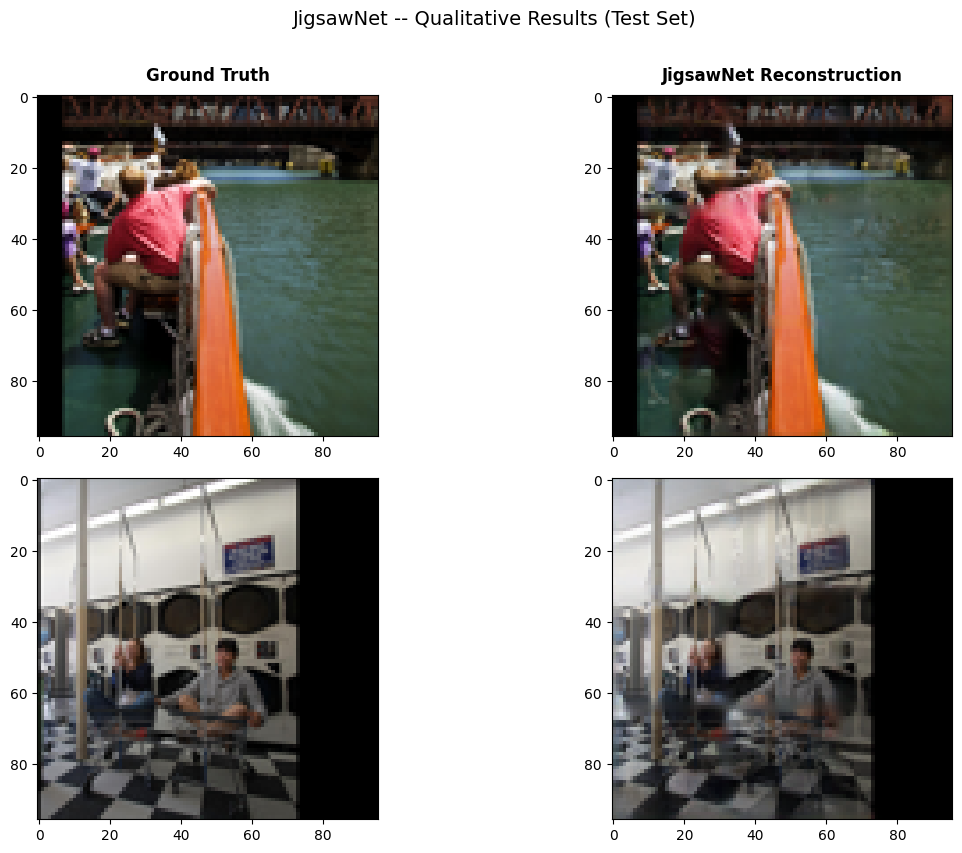

In [ ]:
def visualize_results(model, generator, n_samples=2):
    """Ground truth | JigsawNet reconstruction."""
    Xb, Yb = generator[0]
    preds   = model.predict(Xb, verbose=0)

    fig, axes = plt.subplots(n_samples, 2, figsize=(13, n_samples * 4.2))
    for col, title in enumerate(["Ground Truth", "JigsawNet Reconstruction"]):
        axes[0, col].set_title(title, fontsize=12, fontweight="bold", pad=10)

        axes[0, 0].imshow(np.clip(Yb["reconstruction"][0], 0, 1))
        axes[0, 1].imshow(np.clip(preds["reconstruction"][0], 0, 1))

        axes[1, 0].imshow(np.clip(Yb["reconstruction"][1], 0, 1))
        axes[1, 1].imshow(np.clip(preds["reconstruction"][1], 0, 1))

    plt.suptitle("JigsawNet -- Qualitative Results (Test Set)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

visualize_results(model, test_gen, n_samples=2)

## Save Model Weights

In [ ]:
MODEL_PATH = "jigsaw_network.keras"
model.save(MODEL_PATH)
print(f"Saved: '{MODEL_PATH}'  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")

Saved: 'jigsaw_network.keras'  (57.3 MB)


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import shutil
DRIVE_PATH = "/content/drive/MyDrive/jigsaw_network.keras"
shutil.copy(MODEL_PATH, DRIVE_PATH)
print(f"Uploaded: {DRIVE_PATH}")

## Verify: Download and Reload Model


In [ ]:
FILE_ID = "1LXEbJij1TSGrLyucNhdcs6B-fuNQ0B-U"   #Google Drive file ID for accessing to the weights

import subprocess
subprocess.run(["gdown", FILE_ID, "-O", "jigsaw_network.keras"], check=True)

# register_keras_serializable handles custom classes automatically
loaded_model = keras.models.load_model("jigsaw_network.keras")

print("Model loaded successfully.")
print(f"Trainable parameters: {loaded_model.count_params():,}")
assert loaded_model.count_params() < 6_000_000, "Budget exceeded!"

Xb, _ = test_gen[0]
out   = loaded_model.predict(Xb[:2], verbose=0)
assert out["reconstruction"].shape == (2, 96, 96, 3)
assert out["ordering"].shape       == (2, 9, 9)
print("Shape check        : PASSED")
print("gdown verification : PASSED")

Downloading...
From (original): https://drive.google.com/uc?id=1LXEbJij1TSGrLyucNhdcs6B-fuNQ0B-U
From (redirected): https://drive.google.com/uc?id=1LXEbJij1TSGrLyucNhdcs6B-fuNQ0B-U&confirm=t&uuid=54bb6c55-d5f8-440a-b635-17c1fb05e04a
To: /kaggle/working/jigsaw_network.keras
100%|██████████| 57.3M/57.3M [00:00<00:00, 91.7MB/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause

Model loaded successfully.
Trainable parameters: 4,731,084
Shape check        : PASSED
gdown verification : PASSED


**Which one of layers have weights and their shapes**

In [ ]:
for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        for i, w in enumerate(weights):
            print(f"{layer.name:35s}  weight[{i}]  {str(w.shape):25s}  "
                  f"mean={w.mean():.4f}  std={w.std():.4f}")

shared_encoder                       weight[0]  (3, 3, 3, 32)              mean=-0.0600  std=0.2782
shared_encoder                       weight[1]  (32,)                      mean=0.0084  std=0.0234
shared_encoder                       weight[2]  (3, 3, 32, 32)             mean=-0.0106  std=0.1092
shared_encoder                       weight[3]  (32,)                      mean=0.0216  std=0.0296
shared_encoder                       weight[4]  (3, 3, 32, 64)             mean=-0.0120  std=0.1023
shared_encoder                       weight[5]  (64,)                      mean=0.0185  std=0.0509
shared_encoder                       weight[6]  (3, 3, 64, 64)             mean=-0.0112  std=0.0921
shared_encoder                       weight[7]  (64,)                      mean=-0.0015  std=0.0504
shared_encoder                       weight[8]  (3, 3, 64, 128)            mean=-0.0109  std=0.0852
shared_encoder                       weight[9]  (128,)                     mean=-0.0045  std=0.0372
sha

**Weights of one specific layer:**

In [ ]:
# Sample Layer
layer = model.get_layer("transformer_1").Wq
w = layer.get_weights()[0]
print(f"Shape : {w.shape}")
print(f"Mean  : {w.mean():.4f}")
print(f"Std   : {w.std():.4f}")
print(f"Min   : {w.min():.4f}")
print(f"Max   : {w.max():.4f}")

Shape : (256, 256)
Mean  : -0.0021
Std   : 0.1657
Min   : -0.9443
Max   : 0.9432


In [ ]:
# Inspect one specific layer by name
layer_name = "pos_h1"   # spesific layer's name
w = loaded_model.get_layer(layer_name).get_weights()[0]
print(f"Layer : {layer_name}")
print(f"Shape : {w.shape}")
print(f"Mean  : {w.mean():.4f}")
print(f"Std   : {w.std():.4f}")
print(f"\nvalues:")
print(w)

Layer : pos_h1
Shape : (256, 128)
Mean  : -0.0003
Std   : 0.0888

values:
[[-1.2510440e-02  2.4844876e-03  4.4283152e-02 ...  4.7765788e-02
   3.2889217e-02 -6.1245959e-02]
 [ 4.8431866e-02 -1.2038539e-01  1.7012807e-02 ... -8.1682645e-02
  -3.6961548e-02  1.8892968e-01]
 [ 1.4858280e-01  7.7209726e-02 -7.1275197e-02 ... -4.6288129e-02
   7.7267583e-03  3.8029127e-02]
 ...
 [ 6.6627793e-02  2.0473167e-01  1.1713106e-01 ... -7.1798131e-02
   9.8274484e-02 -7.9589337e-02]
 [ 7.0241302e-05 -2.4667851e-04 -4.2847842e-02 ... -3.7428442e-02
   5.3377051e-02  2.7026197e-02]
 [ 4.6641557e-03 -8.7115411e-03 -1.3588740e-01 ... -1.7930146e-01
  -6.0926042e-02 -6.5197237e-02]]


In [ ]:
# Sepehr Rezaei Melal